# Занятие 14. Практика: кластеризация на простых данных — АВТОРСКОЕ РЕШЕНИЕ

На теоретическом занятии разобраны понятия: **признак**, **расстояние**, **центроид**, **K-Means**,
**иерархическая кластеризация**, **дендрограмма**, **метод локтя**. Здесь эти методы применяются
на данных из двух разных областей — образование и медицина.

**План занятия:**

1. Разбор **примера** — группировка студентов по пройденным модулям курса.
2. **Практика**

В каждой ячейке практики после комментария `# Ваш код` пишется решение; где просят вывод —
он оформляется в ячейке `**Вывод:**` под кодом.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 90
plt.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

---
## Эталонный пример. Пройденные модули курса

Набор `modules.csv` — **34 студента** онлайн-курса и **8 модулей**. Для каждого студента указано
`1` (модуль пройден) или `0` (не пройден):

| Модуль | Тема | Модуль | Тема |
|---|---|---|---|
| HTML | вёрстка страниц | PYTHON | программирование на Python |
| CSS | стили и оформление | STATS | статистика и анализ |
| JS | JavaScript | FIGMA | макеты в Figma |
| SQL | базы данных | UX | проектирование интерфейсов |

Признаков восемь — на плоскости не нарисовать. Но порядок действий тот же, что и в учебном примере
занятия: дендрограмма → каменистая осыпь → разрез дерева → центроиды → сравнение с K-Means.

### Шаг 1. Загрузка и просмотр

In [65]:
df = pd.read_csv('data/modules.csv')
print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (34, 8)


,HTML,CSS,JS,SQL,PYTHON,STATS,FIGMA,UX
0,1,1,1,0,0,0,1,0
1,1,1,1,0,0,0,1,0
2,0,1,1,0,0,0,0,0
3,1,1,1,0,0,0,0,0
4,1,1,1,0,0,0,0,1


Оценим **популярность** каждого модуля — среднее по столбцу (доля прошедших).

In [66]:
df.mean().sort_values(ascending=False).round(2)

HTML      0.50
JS        0.44
CSS       0.41
FIGMA     0.41
UX        0.41
PYTHON    0.38
SQL       0.32
STATS     0.29
dtype: float64

**Наблюдение.** Чаще всего проходят `HTML` (0.50), `JS` (0.44), `CSS`/`FIGMA`/`UX` (0.41);
реже — `SQL` и `STATS`. Похоже, группы соберутся вокруг трёх учебных треков: веб, данные, дизайн.

### Шаг 2. Иерархическая кластеризация и дендрограмма
`linkage` c `method='ward'`, `metric='euclidean'`; `dendrogram` рисует дерево склеек.

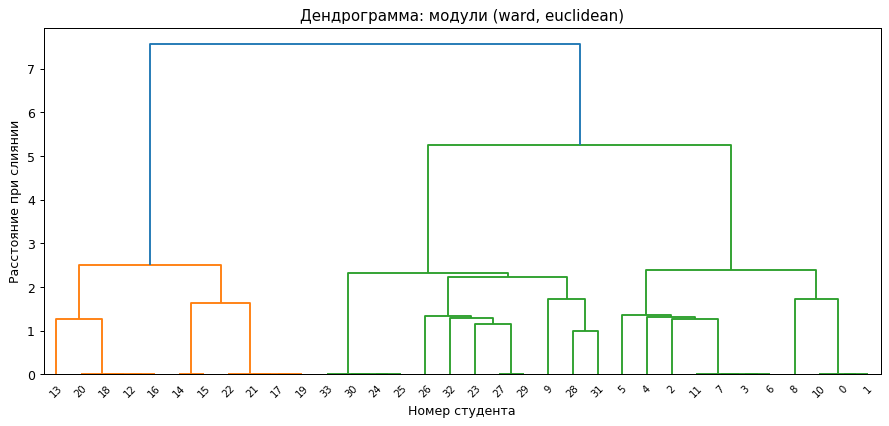

In [67]:
link = linkage(df, method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(link)
plt.title('Дендрограмма: модули (ward, euclidean)')
plt.xlabel('Номер студента'); plt.ylabel('Расстояние при слиянии')
plt.show()

**Наблюдение.** Видны **3 крупные ветви** — три устойчивые группы студентов.

### Шаг 3. Число групп: каменистая осыпь
Смотрим расстояния слияний в обратном порядке и ищем точку, после которой график перестаёт резко падать.

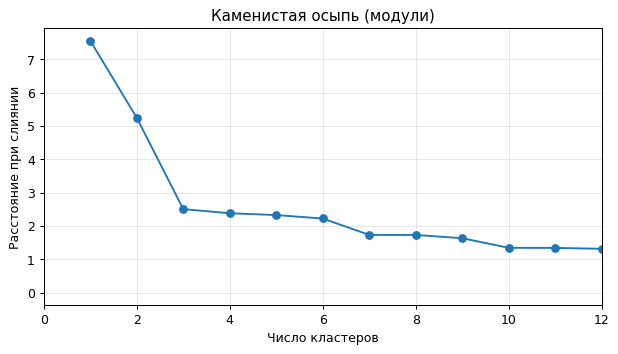

Первые расстояния: [7.6, 5.2, 2.5, 2.4, 2.3]


In [68]:
dist_rev = link[:, 2][::-1]
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(dist_rev) + 1), dist_rev, marker='o')
plt.title('Каменистая осыпь (модули)')
plt.xlabel('Число кластеров'); plt.ylabel('Расстояние при слиянии')
plt.xlim(0, 12); plt.grid(True, alpha=0.3)
plt.show()
print('Первые расстояния:', [round(x, 1) for x in dist_rev[:5]])

**Наблюдение.** Резкое падение до 3 кластеров (7.6 → 5.2 → 2.5), дальше линия почти плоская.
Точка перелома — `K = 3`.

### Шаг 4. Разрез дерева — `fcluster`

In [69]:
df['cluster'] = fcluster(link, 3, criterion='maxclust')
df.groupby('cluster').size()

cluster
1    11
2    12
3    11
dtype: int64

**Наблюдение.** Группы получились не вырожденными (примерно 11 / 12 / 11 студентов) — разбиение осмысленно.

### Шаг 5. Профили групп (центроиды)
Для бинарных данных `groupby().mean()` — это **доля прошедших модуль** внутри группы:
близко к 1 — модуль характерен для группы, близко к 0 — нет.

In [70]:
df.groupby('cluster').mean().round(2)

,HTML,CSS,JS,SQL,PYTHON,STATS,FIGMA,UX
cluster,,,,,,,,
1,0.00,0.00,0.45,0.91,1.00,0.82,0.00,0.00
2,0.58,0.25,0.00,0.08,0.08,0.08,0.83,1.00
3,0.91,1.00,0.91,0.00,0.09,0.00,0.36,0.18


**Наименование групп по профилям:**

- **Data-трек** — высокие `SQL`, `PYTHON`, `STATS`, веб- и дизайн-модули ≈ 0.
- **Дизайн-трек** — высокие `UX` и `FIGMA`, немного `HTML`.
- **Веб-трек** — высокие `HTML`, `CSS`, `JS`.

### Шаг 6. K-Means и сравнение методов
Применяем второй метод и через `crosstab` проверяем совпадение групп с иерархией.

In [71]:
X = df.drop(columns='cluster')
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans'] = km.fit_predict(X)
pd.crosstab(df['cluster'], df['kmeans'])

kmeans,0,1,2
cluster,,,
1,0,11,0
2,1,0,11
3,11,0,0


**Наблюдение.** Номера групп у двух методов свои, поэтому главная диагональ здесь ни при чём —
смотреть надо на структуру таблицы. Каждый иерархический кластер почти целиком укладывается в **один**
столбец K-Means: кластеры 1 и 3 (по 11 объектов) совпали полностью, а у кластера 2 из его 12 объектов
11 попали в один столбец и лишь **один** — в другой. Итого расхождение — **один объект из 34**:
методы выделили практически одни и те же группы, и эта согласованность подтверждает разбиение.

**Вывод по эталонному примеру.** Один и тот же порядок действий — дендрограмма, каменистая осыпь,
`fcluster`, центроиды, сравнение с K-Means — позволил выделить и содержательно описать три учебных
трека. Далее эти шаги выполняются самостоятельно.

---
## Практика

Ниже **10 заданий** на двух наборах данных, всего **30 баллов**.

- **Задания 1–6** — набор `students.csv` (навыки студентов).
- **Задания 7–10** — набор `health.csv` (показатели здоровья пациентов).

В каждой ячейке после `# Ваш код` напишите решение. Где просят прокомментировать результат —
заполните ячейку `**Вывод:**` под кодом.

Параметры расчётов везде одинаковы: `linkage(method='ward', metric='euclidean')`,
`fcluster(..., criterion='maxclust')`, `KMeans(..., random_state=42, n_init=10)`.

### Знакомство с датасетами практики

Перед решением заданий посмотрим на оба набора: сколько строк и столбцов, как выглядят первые записи
и какие в них значения.

**Набор 1 — навыки студентов** (`students.csv`). Столбец `NAME` — имя студента, `S1–S10` — баллы навыков.

In [72]:
students_preview = pd.read_csv('data/students.csv')
print('Размер:', students_preview.shape)
students_preview.head()

Размер: (18, 11)


,NAME,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
0,Anna,9,9,9,9,4,4,4,4,6,4
1,Boris,10,9,7,10,4,4,5,5,4,3
2,Clara,8,9,9,10,4,4,4,4,5,4
3,David,9,9,9,8,5,5,3,5,4,4
4,Erik,9,8,9,9,4,3,4,4,4,4


**Набор 2 — показатели здоровья** (`health.csv`) — шесть медицинских показателей.

In [73]:
health_preview = pd.read_csv('data/health.csv')
print('Размер:', health_preview.shape)
health_preview.head()

Размер: (310, 6)


,age,bmi,glucose,sbp,pulse,chol
0,51,25.7,101,140,75,275
1,66,32.9,135,177,81,226
2,71,32.6,137,155,79,226
3,67,33.0,134,156,84,286
4,65,26.7,102,149,72,265


Посмотрим на разброс показателей здоровья — минимум, максимум и среднее по каждому столбцу.

In [74]:
health_preview.describe().round(1)

,age,bmi,glucose,sbp,pulse,chol
count,310.0,310.0,310.0,310.0,310.0,310.0
mean,53.5,26.2,105.9,134.0,70.7,208.2
std,9.9,4.6,24.3,17.0,7.0,45.3
min,33.0,17.4,63.0,100.0,54.0,120.0
25%,46.0,22.6,87.0,121.0,66.0,177.0
50%,53.0,25.5,101.0,131.0,70.5,205.0
75%,61.0,29.7,117.0,146.0,75.0,242.0
max,76.0,38.3,168.0,177.0,92.0,320.0


**Наблюдение.** Показатели живут в **разных диапазонах**: `pulse` — десятки (~60-90),
а `chol` — сотни (~150-350). Из-за этого «крупные» признаки будут доминировать в расстоянии —
поэтому в задании 7 данные придётся **стандартизовать**.

### Набор 1. Навыки студентов

18 студентов прошли оценку по 10 навыкам (баллы 1–10). Навыки **S1–S4** — аналитические
(S1 логика, S2 математика, S3 алгоритмы, S4 анализ данных), **S5–S10** — гуманитарные и
коммуникативные (S5 письменная речь, S6 презентация, S7 работа в команде, S8 иностранный язык,
S9 креативность, S10 эмпатия).

### <font color='DarkOrange'>Задание 1 [2 балла]</font>

Загрузите `data/students.csv`. Сохраните список названий навыков `S1–S10` в переменную `skills`.
Выведите размер таблицы (`.shape`).

In [88]:
stu = pd.read_csv('data/students.csv')
skills = [f'S{i}' for i in range(1, 11)]
print(stu.shape)
# Ответ: (18, 11) — 18 студентов: имя + 10 навыков

(18, 11)


### <font color='DarkOrange'>Задание 2 [3 балла]</font>

Постройте иерархическую кластеризацию по навыкам `S1–S10`
(`linkage`, `method='ward'`, `metric='euclidean'`) и дендрограмму с именами студентов
(`labels=stu['NAME'].tolist()`).

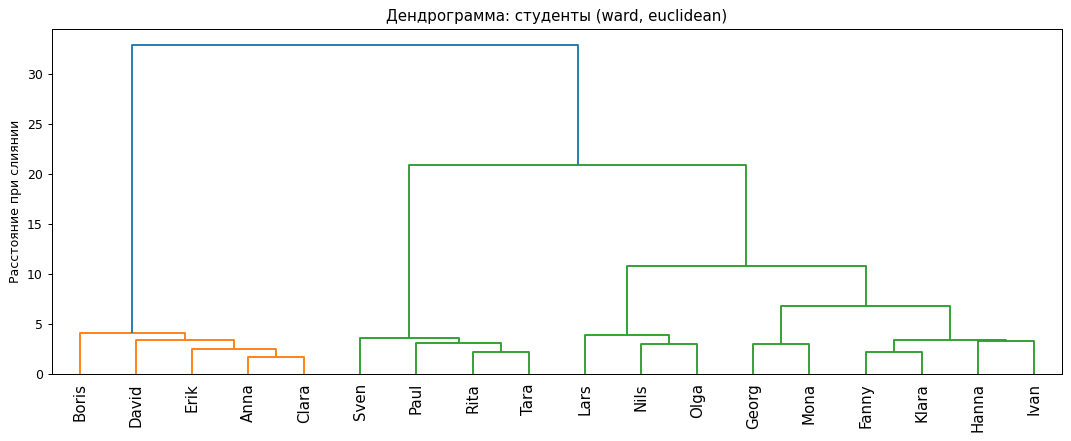

In [89]:
link_s = linkage(stu[skills], method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(link_s, labels=stu['NAME'].tolist(), leaf_rotation=90)
plt.title('Дендрограмма: студенты (ward, euclidean)')
plt.ylabel('Расстояние при слиянии')
plt.tight_layout()
plt.show()
# Ответ: видны 3 крупные ветви

**Вывод:** на дендрограмме выделяются **3 крупные ветви** — три устойчивые группы студентов.

### <font color='DarkOrange'>Задание 3 [3 балла]</font>

Постройте каменистую осыпь (расстояния слияний в обратном порядке) и по ней определите
подходящее число групп.

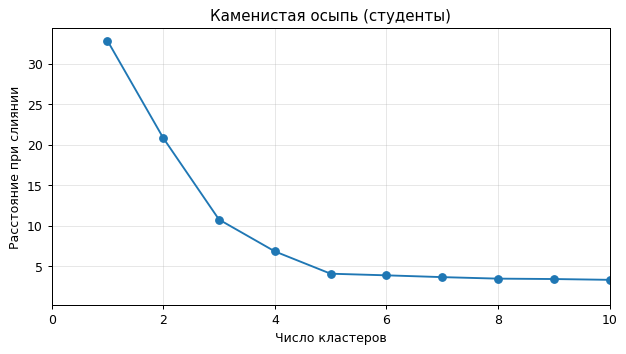

Первые расстояния: [32.9, 20.9, 10.8, 6.8, 4.1]


In [90]:
dist_rev = link_s[:, 2][::-1]
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(dist_rev) + 1), dist_rev, marker='o')
plt.title('Каменистая осыпь (студенты)')
plt.xlabel('Число кластеров'); plt.ylabel('Расстояние при слиянии')
plt.xlim(0, 10); plt.grid(True, alpha=0.3)
plt.show()
print('Первые расстояния:', [round(x, 1) for x in dist_rev[:5]])
# Ответ: 32.9 -> 20.9 -> 10.8 -> 6.8; перелом на K = 3

**Вывод:** расстояния резко падают до 3 групп (32.9 → 20.9 → 10.8), дальше почти плоско —
естественное число групп **K = 3**; при детализации осмысленно и **K = 4**.

### <font color='DarkOrange'>Задание 4 [3 балла]</font>

Разрежьте дерево (`fcluster`, `criterion='maxclust'`) на **3** и на **4** кластера.
Для каждого разбиения выведите размеры групп.

In [91]:
stu['cl3'] = fcluster(link_s, 3, criterion='maxclust')
stu['cl4'] = fcluster(link_s, 4, criterion='maxclust')
print('Размеры при 3 кластерах:', dict(stu.groupby('cl3').size()))
print('Размеры при 4 кластерах:', dict(stu.groupby('cl4').size()))
# Ответ: 3 кластера -> {1:5, 2:4, 3:9}; 4 кластера -> {1:5, 2:4, 3:3, 4:6}

Размеры при 3 кластерах: {1: 5, 2: 4, 3: 9}
Размеры при 4 кластерах: {1: 5, 2: 4, 3: 3, 4: 6}


### <font color='DarkOrange'>Задание 5 [3 балла]</font>

Для разбиения на **4** кластера вычислите центроиды — средние баллы по навыкам `S1–S10`
(`groupby('cl4')[skills].mean()`, округлите до 1 знака). По профилям **содержательно опишите группы**.

In [79]:
stu.groupby('cl4')[skills].mean().round(1)
# Ответ: центроиды 4 групп (см. вывод ниже)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
cl4,,,,,,,,,,
1,9.0,8.8,8.6,9.2,4.2,4.0,4.0,4.4,4.6,3.8
2,9.0,9.2,9.2,9.2,8.8,8.8,9.2,9.2,9.0,9.2
3,6.3,7.0,6.7,5.3,8.0,8.0,8.7,7.3,7.3,8.0
4,4.2,4.0,3.8,4.3,8.3,8.8,8.5,9.2,8.5,8.8


**Вывод:** четыре группы студентов по профилям центроидов:
- **Аналитики** — высокие S1–S4 (~9), низкие гуманитарные S5–S10 (~4).
- **Универсалы** — высокие баллы почти по всем навыкам (~9).
- **Гуманитарии со средней аналитикой** — умеренные S1–S4 (~6), высокие S5–S10 (~8).
- **Гуманитарии** — низкие S1–S4 (~4), высокие S5–S10 (~8.7).

### <font color='DarkOrange'>Задание 6 [3 балла]</font>

Выполните `KMeans` на **4** кластера (`random_state=42`, `n_init=10`) по навыкам `S1–S10`
и сравните с иерархическим разбиением `cl4` через `pd.crosstab`. Согласуются ли методы?

In [92]:
km_s = KMeans(n_clusters=4, random_state=42, n_init=10)
stu['kmeans4'] = km_s.fit_predict(stu[skills])
pd.crosstab(stu['cl4'], stu['kmeans4'])
# Ответ: каждый кластер целиком совпал с одной группой K-Means (одно-однозначное соответствие)

kmeans4,0,1,2,3
cl4,,,,
1,5,0,0,0
2,0,4,0,0
3,0,0,0,3
4,0,0,6,0


**Вывод:** номера групп у методов свои, но каждый иерархический кластер **целиком** совпал с одной
группой K-Means (в каждой строке заполнен ровно один столбец, без расхождений). Иерархия и K-Means
выделили **одни и те же** 4 группы — разбиение устойчиво.

### Набор 2. Показатели здоровья пациентов

Файл `health.csv` — **310 пациентов** и 6 медицинских показателей:

| Показатель | Что означает | Показатель | Что означает |
|---|---|---|---|
| `age` | возраст, годы | `sbp` | систолическое давление, мм рт.ст. |
| `bmi` | индекс массы тела | `pulse` | пульс покоя, уд/мин |
| `glucose` | глюкоза натощак, мг/дл | `chol` | холестерин, мг/дл |

Показатели измерены в **разных шкалах** (пульс ~60-90, а холестерин ~150-350).
Задача — выделить **группы риска** сердечно-сосудистых заболеваний.

### <font color='DarkOrange'>Задание 7 [3 балла]</font>

Загрузите `data/health.csv`. Стандартизуйте все 6 показателей
через `StandardScaler` (результат — в `DataFrame` с теми же названиями столбцов).
Выведите размер набора.

In [81]:
hlt = pd.read_csv('data/health.csv')
feat = ['age', 'bmi', 'glucose', 'sbp', 'pulse', 'chol']
Xh = pd.DataFrame(StandardScaler().fit_transform(hlt[feat]), columns=feat)
print(hlt.shape)
Xh.head()
# Ответ: (310, 6) — 310 пациентов, 6 показателей

(310, 6)


,age,bmi,glucose,sbp,pulse,chol
0,-0.251348,-0.114372,-0.200251,0.353405,0.619154,1.475405
1,1.268506,1.460450,1.202169,2.528056,1.477935,0.392938
2,1.775124,1.394833,1.284664,1.235020,1.191675,0.392938
3,1.369830,1.482323,1.160921,1.293794,1.907326,1.718408
4,1.167182,0.104353,-0.159003,0.882374,0.189763,1.254494


### <font color='DarkOrange'>Задание 8 [3 балла]</font>

На **стандартизованных** данных постройте иерархическую кластеризацию
(`method='ward'`, `metric='euclidean'`) и каменистую осыпь. Определите число групп риска.
Дендрограмму стройте с `truncate_mode='lastp', p=20` (объектов много).

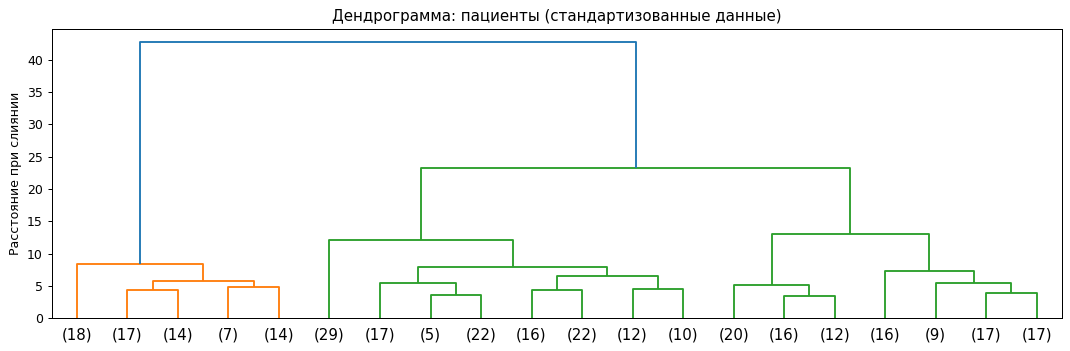

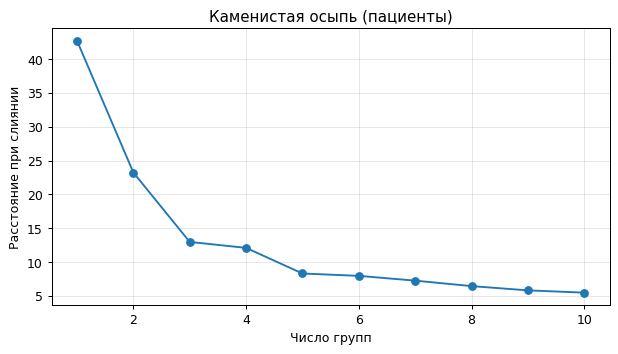

Первые расстояния: [42.7, 23.2, 13.0, 12.1, 8.3, 8.0]


In [82]:
link_h = linkage(Xh, method='ward', metric='euclidean')

plt.figure(figsize=(12, 4))
dendrogram(link_h, truncate_mode='lastp', p=20)
plt.title('Дендрограмма: пациенты (стандартизованные данные)')
plt.ylabel('Расстояние при слиянии'); plt.tight_layout(); plt.show()

dist_rev = link_h[:, 2][::-1][:10]
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(dist_rev) + 1), dist_rev, marker='o')
plt.title('Каменистая осыпь (пациенты)')
plt.xlabel('Число групп'); plt.ylabel('Расстояние при слиянии')
plt.grid(True, alpha=0.3); plt.show()
print('Первые расстояния:', [round(x, 1) for x in dist_rev[:6]])
# Ответ: 42.7 -> 23.2 -> 13.0 -> 12.1; перелом -> K = 3

**Вывод:** расстояния резко падают до 3 групп (42.7 -> 23.2 -> 13.0), дальше линия почти плоская.
Число групп риска **K = 3**.

### <font color='DarkOrange'>Задание 9 [4 балла]</font>

Разрежьте дерево на **3** группы (`fcluster`), выведите размеры групп и центроиды
(средние показатели по группам, округление до 1). **Содержательно опишите** каждую группу
как уровень риска.

In [83]:
hlt['cluster'] = fcluster(link_h, 3, criterion='maxclust')
print('Размеры групп:', dict(hlt.groupby('cluster').size()))
hlt.groupby('cluster')[feat].mean().round(1)
# Ответ: размеры {70, 133, 107}; профили — см. вывод

Размеры групп: {1: 70, 2: 133, 3: 107}


,age,bmi,glucose,sbp,pulse,chol
cluster,,,,,,
1,65.8,32.8,145.0,159.4,79.6,209.7
2,45.3,22.1,85.9,120.1,65.0,209.8
3,55.5,27.0,105.1,134.6,71.9,205.3


**Вывод:** три группы риска (размеры ~ 133 / 107 / 70):
- **Низкий риск** (~133 чел.) — молодые (возраст ~45), нормальный `bmi` (~22), глюкоза, давление и пульс в норме.
- **Умеренный риск** (~107 чел.) — средние значения по всем показателям (возраст ~55, `bmi` ~27, `sbp` ~135).
- **Высокий риск** (~70 чел.) — возраст ~66, `bmi` ~33, повышенные `glucose` (~145), `sbp` (~159), `pulse` (~80).

Холестерин `chol` почти одинаков во всех группах (~205-210) — сам по себе он группы риска **не различает**.

### <font color='DarkOrange'>Задание 10 [3 балла]</font>

Выполните иерархическую кластеризацию на **исходных** (нестандартизованных) показателях
на 3 группы и сравните разбиение со стандартизованным (`cluster`) через `pd.crosstab`.
Объясните результат.

In [84]:
link_raw = linkage(hlt[feat], method='ward', metric='euclidean')
hlt['cluster_raw'] = fcluster(link_raw, 3, criterion='maxclust')
pd.crosstab(hlt['cluster'], hlt['cluster_raw'])
# Ответ: объекты НЕ по диагонали — разбиения расходятся

cluster_raw,1,2,3
cluster,,,
1,19,1,50
2,92,41,0
3,79,28,0


**Вывод:** без стандартизации разбиение **заметно отличается** — в `crosstab` объекты
размазаны сразу по нескольким ячейкам в каждой строке, а не собираются по одному столбцу (нет
одно-однозначного соответствия групп). Причина: `chol` и `glucose` измерены в больших числах,
и в евклидовом расстоянии доминирует холестерин (у него самый большой разброс), хотя группы риска
он не различает. Стандартизация уравнивает вклад всех показателей — только тогда выделяются
корректные группы риска. **На данных с разными шкалами стандартизация обязательна.**